In [38]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/datasets/namigabbasov/consumer-complaint-dataset/complaints.csv


# NLP-Analyse von Verbraucherbeschwerden
Extraktion der häufigsten Themen aus dem CFPB Consumer Complaint Dataset mittels LDA und NMF.

## 1. Datenexploration

In [39]:
import pandas as pd

PFAD = "/kaggle/input/datasets/namigabbasov/consumer-complaint-dataset/complaints.csv"

vorschau = pd.read_csv(PFAD, nrows=5)
print(vorschau.columns.tolist())
vorschau

['Unnamed: 0', 'product_5', 'narrative', 'Product', 'Date received', 'Sub-product', 'Issue', 'Sub-issue', 'Company', 'State', 'Timely response?']


,Unnamed: 0,product_5,narrative,Product,Date received,Sub-product,Issue,Sub-issue,Company,State,Timely response?
0,234,Credit Reporting,Dear Possible Financial Inc you guyss aree rep...,Credit reporting or other personal consumer re...,2024-07-27,Credit reporting,Incorrect information on your report,Account information incorrect,Possible Financial Inc,MI,Yes
1,240,Debt Collection,"XXXX XXXX XXXX ( debt collector ), sent my boy...",Debt collection,2024-07-27,I do not know,Threatened to contact someone or share informa...,Talked to a third-party about your debt,BlueChip Financial,TX,Yes
2,257,Credit Reporting,I been receiving alerts my information was fou...,Credit reporting or other personal consumer re...,2024-07-23,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,FC HoldCo LLC,SC,Yes
3,271,Credit Reporting,Subject : Dispute of Inaccurate Information on...,Credit reporting or other personal consumer re...,2024-07-27,Credit reporting,Improper use of your report,Reporting company used your report improperly,CORELOGIC INC,GA,Yes
4,276,Loans,They allowed me to use the account for about a...,"Payday loan, title loan, personal loan, or adv...",2024-07-26,Payday loan,Received a loan you didn't apply for,NaN,MoneyLion Inc.,PA,Yes


## 2. Daten laden und Stichprobe ziehen

In [40]:
# 500 Beschwerden ziehen - in Bloecken, um Speicher zu schonen
stichprobe = []

for block in pd.read_csv(PFAD, usecols=["narrative", "product_5"], chunksize=100_000):
    block = block.dropna(subset=["narrative"])          # leere Texte raus
    stichprobe.append(block.sample(frac=0.0005, random_state=42))

df = pd.concat(stichprobe)
df = df.sample(n=500, random_state=42).reset_index(drop=True)

print("Anzahl Beschwerden:", len(df))
df.head(3)

Anzahl Beschwerden: 500


,product_5,narrative
0,Credit Card Services,I HAVE SENT CAPITL ONE SEVERAL STTEMENTS PROVI...
1,Credit Card Services,I AM FURIOUS!! WHY IF MY PAYMENT IS POSTED TO ...
2,Credit Reporting,XXXX XXXX XXXX is reporting on all XXXX credit...


In [41]:
# Speichern
df.to_csv("/kaggle/working/stichprobe_500.csv", index=False)
print("Gespeichert.")

Gespeichert.


In [42]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# NLTK-Datenpakete herunterladen (einmalig pro Session)
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("punkt")
nltk.download("punkt_tab")

stopp = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
print("Bereit. Anzahl Stoppwoerter:", len(stopp))

Bereit. Anzahl Stoppwoerter: 198


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 3. Vorverarbeitung

In [43]:
def bereinige(text):
    text = text.lower()                          # alles klein
    text = text.replace("xxxx", " ")             # Anonymisierungs-Platzhalter raus
    text = re.sub(r"http\S+|www\.\S+", " ", text)# URLs raus
    text = re.sub(r"[^a-z\s]", " ", text)        # nur Buchstaben behalten (Zahlen/Sonderzeichen raus)
    tokens = word_tokenize(text)                 # in einzelne Woerter zerlegen
    tokens = [
        lemmatizer.lemmatize(w)                  # auf Grundform bringen
        for w in tokens
        if w not in stopp and len(w) > 2         # Stoppwoerter und sehr kurze Woerter raus
    ]
    return " ".join(tokens)

# Auf alle 500 Beschwerden anwenden
df["clean"] = df["narrative"].apply(bereinige)

# Vorher-Nachher-Vergleich
print("VORHER:\n", df["narrative"].iloc[0][:300])
print("\nNACHHER:\n", df["clean"].iloc[0][:300])

VORHER:
 I HAVE SENT CAPITL ONE SEVERAL STTEMENTS PROVING MY ADDRESS, IDENTITY AND PAY STUBS THEY STILL WONT UNRESTRICT THE ACCTS INTERFERING WITH MY ABILITY TO BUILD MY CREDIT

NACHHER:
 sent capitl one several sttements proving address identity pay stub still wont unrestrict accts interfering ability build credit


## 4. Vektorisierung (Bag-of-Words & TF-IDF)

In [44]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

texte = df["clean"].tolist()

# Bag-of-Words (rohe Haeufigkeiten) - Eingabe fuer LDA
bow_vectorizer = CountVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.9)
bow = bow_vectorizer.fit_transform(texte)

# TF-IDF (gewichtet) - Eingabe fuer NMF
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.9)
tfidf = tfidf_vectorizer.fit_transform(texte)

print("BoW-Matrix:  ", bow.shape)
print("TF-IDF-Matrix:", tfidf.shape)
print("\nBeispiel-Merkmale:", bow_vectorizer.get_feature_names_out()[100:110])

BoW-Matrix:   (500, 5789)
TF-IDF-Matrix: (500, 5789)

Beispiel-Merkmale: ['account incorrect' 'account information' 'account late' 'account like'
 'account line' 'account listed' 'account made' 'account make'
 'account man' 'account mine']


## 5. Themenextraktion mit LDA und NMF

In [45]:
from sklearn.decomposition import LatentDirichletAllocation

N_THEMEN = 5

lda = LatentDirichletAllocation(n_components=N_THEMEN, random_state=42)
lda.fit(bow)

# Hilfsfunktion: die Top-Woerter je Thema ausgeben
def zeige_themen(modell, vectorizer, n_woerter=10):
    woerter = vectorizer.get_feature_names_out()
    for i, thema in enumerate(modell.components_):
        top = [woerter[j] for j in thema.argsort()[-n_woerter:]][::-1]
        print(f"Thema {i+1}: {', '.join(top)}")

print("=== LDA (5 Themen) ===")
zeige_themen(lda, bow_vectorizer)

=== LDA (5 Themen) ===
Thema 1: claim, debt, collection, credit, reporting, well, account, fargo, well fargo, information
Thema 2: consumer, information, section, reporting, account, agency, reporting agency, state, consumer reporting, right
Thema 3: balance, balance balance, number, item, address, lease, section, account, report, loan
Thema 4: credit, report, account, credit report, information, reporting, inquiry, payment, bureau, date
Thema 5: account, payment, credit, bank, time, card, would, told, call, received


In [46]:
from sklearn.decomposition import NMF

nmf = NMF(n_components=N_THEMEN, random_state=42, init="nndsvd", max_iter=400)
nmf.fit(tfidf)

print("=== NMF (5 Themen) ===")
zeige_themen(nmf, tfidf_vectorizer)

=== NMF (5 Themen) ===
Thema 1: section, state, right, reporting, account, violated right, right privacy, instruction, section state, written instruction
Thema 2: credit, report, credit report, inquiry, account, bureau, item, information, reporting, credit bureau
Thema 3: payment, account, bank, call, card, loan, money, time, told, called
Thema 4: consumer, consumer reporting, section, information, reporting, reporting agency, state, agency, item information, person
Thema 5: theft, identity, identity theft, victim, victim identity, consumer, block, remove, account, file


## 6. Evaluierung: Kohärenzvergleich und Wahl der Themenzahl

In [47]:
import gensim
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

# Texte in Token-Listen umwandeln (gensim braucht Woerter, keine Strings)
token_texte = [t.split() for t in df["clean"]]
woerterbuch = Dictionary(token_texte)

def kohaerenz(modell, vectorizer):
    woerter = vectorizer.get_feature_names_out()
    themen = [
        [woerter[j] for j in thema.argsort()[-10:]]
        for thema in modell.components_
    ]
    cm = CoherenceModel(topics=themen, texts=token_texte,
                        dictionary=woerterbuch, coherence="c_v")
    return cm.get_coherence()

print("Kohaerenz LDA:", round(kohaerenz(lda, bow_vectorizer), 4))
print("Kohaerenz NMF:", round(kohaerenz(nmf, tfidf_vectorizer), 4))

Kohaerenz LDA: 0.4802
Kohaerenz NMF: 0.6178


In [48]:
print("Themenzahl-Vergleich (c_v-Kohaerenz):\n")
print(f"{'k':>3} | {'LDA':>7} | {'NMF':>7}")
print("-" * 25)

for k in [5, 8, 10]:
    lda_k = LatentDirichletAllocation(n_components=k, random_state=42).fit(bow)
    nmf_k = NMF(n_components=k, random_state=42, init="nndsvd", max_iter=400).fit(tfidf)
    c_lda = kohaerenz(lda_k, bow_vectorizer)
    c_nmf = kohaerenz(nmf_k, tfidf_vectorizer)
    print(f"{k:>3} | {c_lda:>7.4f} | {c_nmf:>7.4f}")

Themenzahl-Vergleich (c_v-Kohaerenz):

  k |     LDA |     NMF
-------------------------
  5 |  0.4802 |  0.6178
  8 |  0.4860 |  0.5793
 10 |  0.4854 |  0.5501


## 7. Ergebnisdarstellung

In [49]:
import pandas as pd

# Finales Modell: NMF mit k=5
final_nmf = NMF(n_components=5, random_state=42, init="nndsvd", max_iter=400).fit(tfidf)
woerter = tfidf_vectorizer.get_feature_names_out()

# Top-8-Begriffe je Thema in eine Tabelle
tabelle = {}
for i, thema in enumerate(final_nmf.components_):
    top = [woerter[j] for j in thema.argsort()[-8:]][::-1]
    tabelle[f"Thema {i+1}"] = top

themen_df = pd.DataFrame(tabelle)
themen_df.index = [f"Begriff {i+1}" for i in range(8)]
themen_df

,Thema 1,Thema 2,Thema 3,Thema 4,Thema 5
Begriff 1,section,credit,payment,consumer,theft
Begriff 2,state,report,account,consumer reporting,identity
Begriff 3,right,credit report,bank,section,identity theft
Begriff 4,reporting,inquiry,call,information,victim
Begriff 5,account,account,card,reporting,victim identity
Begriff 6,violated right,bureau,loan,reporting agency,consumer
Begriff 7,right privacy,item,money,state,block
Begriff 8,instruction,information,time,agency,remove


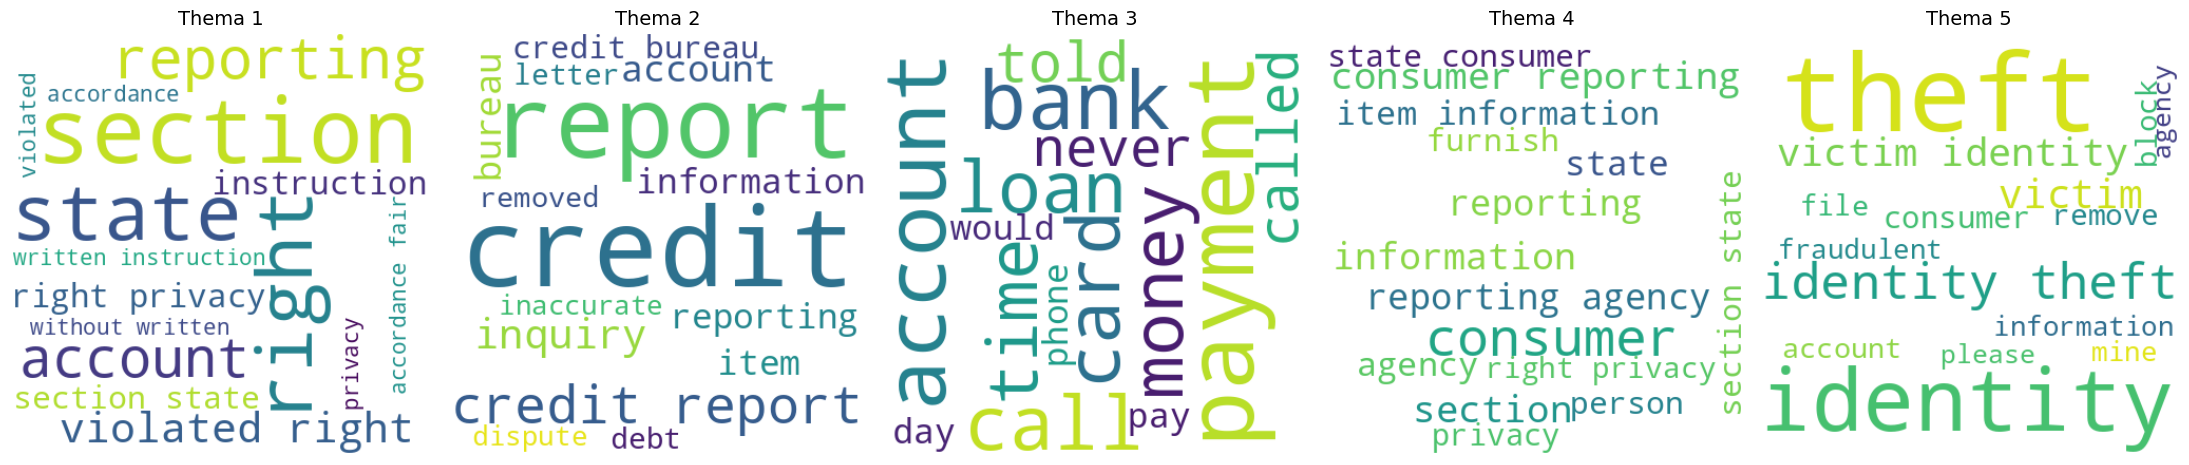

In [50]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for i, thema in enumerate(final_nmf.components_):
    # Begriffe mit ihren Gewichten als Grundlage fuer die Cloud
    gewichte = {woerter[j]: thema[j] for j in thema.argsort()[-15:]}
    wc = WordCloud(width=400, height=400, background_color="white").generate_from_frequencies(gewichte)
    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(f"Thema {i+1}", fontsize=14)
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/themen_wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()

In [51]:
with open("/kaggle/working/requirements.txt", "w") as f:
    f.write("pandas\n")
    f.write("scikit-learn\n")
    f.write("nltk\n")
    f.write("gensim\n")
    f.write("matplotlib\n")
    f.write("wordcloud\n")

print("requirements.txt erstellt:")
print(open("/kaggle/working/requirements.txt").read())

requirements.txt erstellt:
pandas
scikit-learn
nltk
gensim
matplotlib
wordcloud

